In [124]:
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itables import show
import time as tm
from src.A_Data_analysis import fleet_analysis
from src.A_Data_analysis import assignment_analysis
from src.A_Data_analysis import productivity_analysis
from src.A_Data_analysis import productivity_analysis
from src.B_Model_fitting import retirement_prio
from src.B_Model_fitting import assignment_multilogit
# importlib.reload(fleet_analysis)
importlib.reload(assignment_analysis)
# importlib.reload(productivity_analysis)
# importlib.reload(retirement_prio)
importlib.reload(assignment_multilogit)

['C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Scripts\\python313.zip', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv', '', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Lib\\site-packages']


<module 'src.B_Model_fitting.assignment_multilogit' from 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\src\\B_Model_fitting\\assignment_multilogit.py'>

# Fleet model

## Loading data

In [33]:
db_full = pd.read_excel('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet/fleet_extract_treated_final.xlsx')
db_full['Aircraft Type'] = db_full['Type']+' '+db_full['Model'].astype(str)

### Possibility to add filters on the aircraft size, aircraft model, etc...
db_selec = db_full[['Aircraft Type','Engine', 'Delivery Date', 'Status', 'Date']].rename(columns={'Date':'Event Date'})
db_r = fleet_analysis.retirement_ranking(db_selec)

In [34]:
len(db_r['Aircraft Type'].unique())

616

## Data analysis

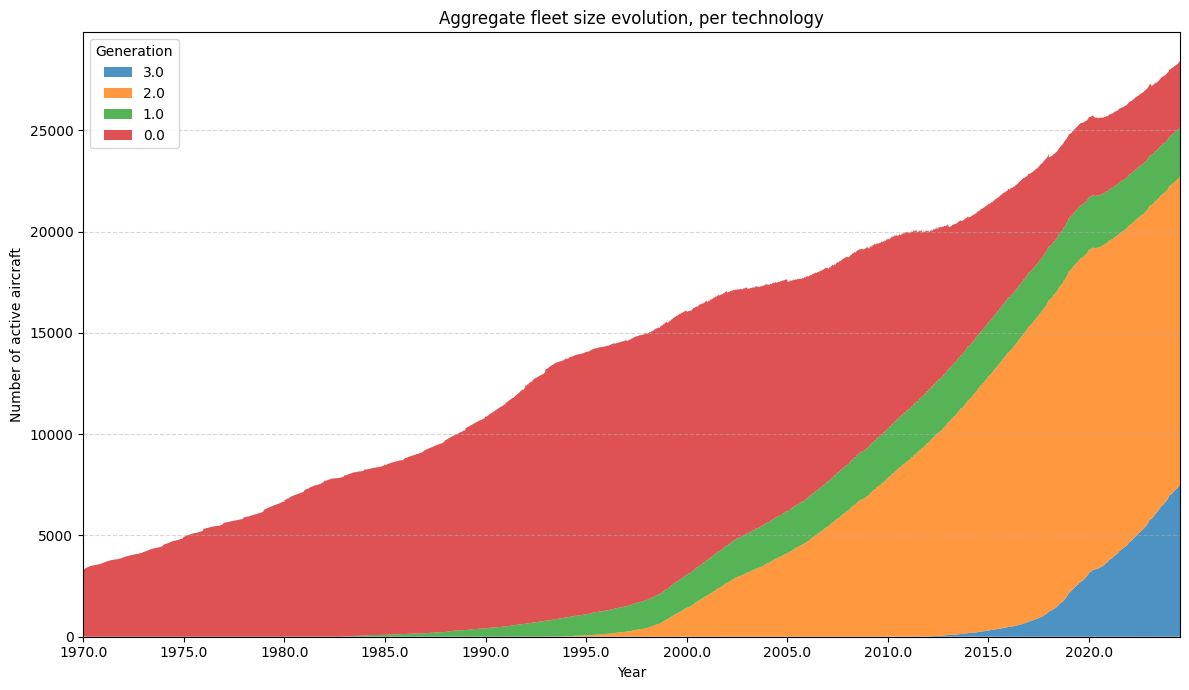

In [58]:
fleet_analysis.visu_fleet(db_selec)

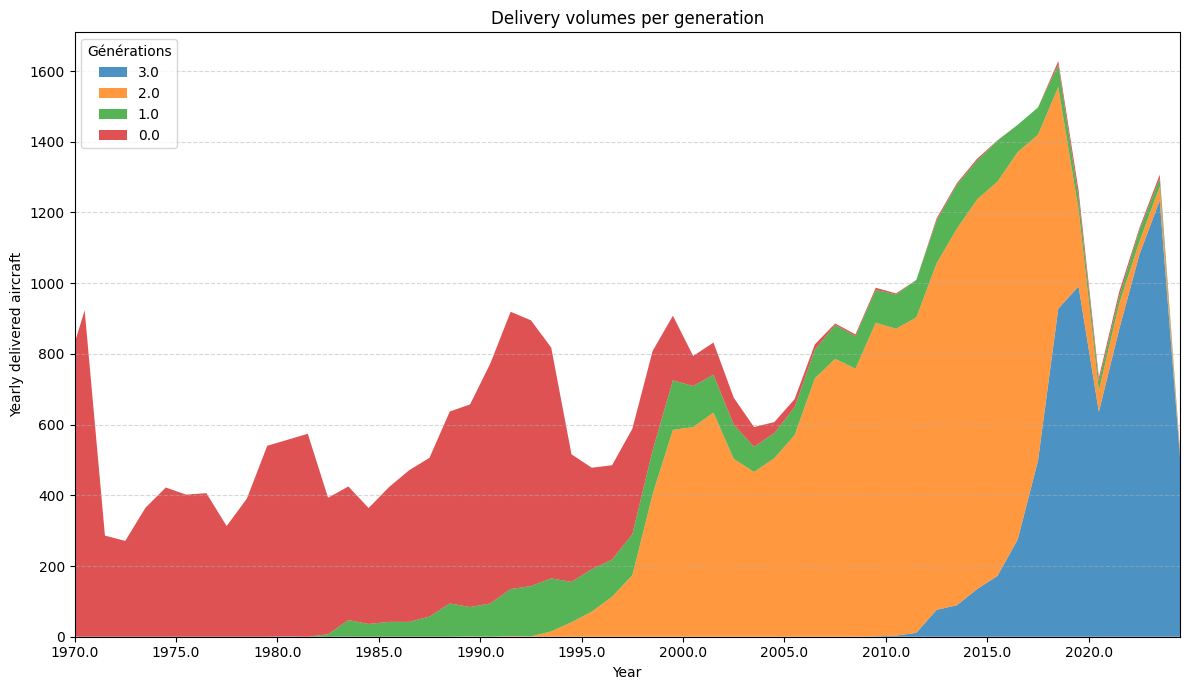

In [59]:
fleet_analysis.visu_prod(db_selec, reso = 1)

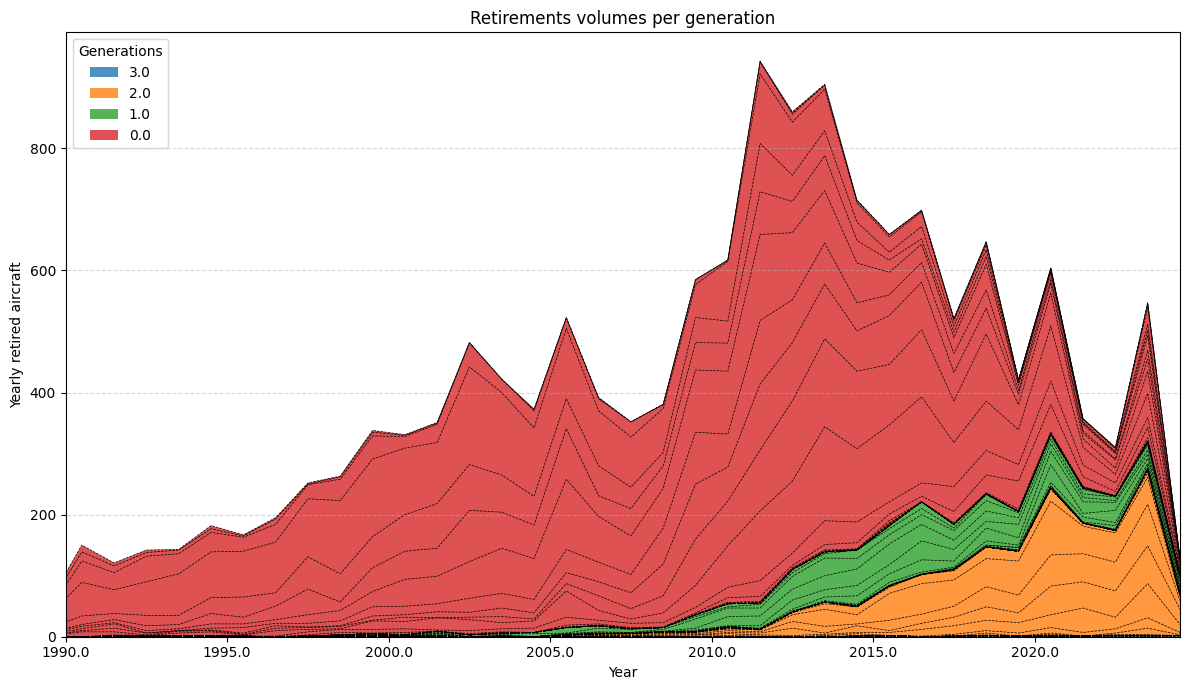

In [87]:
fleet_analysis.visu_retirements(db_selec, reso_1 = 1, reso_2 = 3)

## Model training

In [27]:
df_stat = retirement_prio.setting_df(db_r)

0: -160075.95568943827, -160075.95244566465, -160075.9500347093, -160075.94818342588, -160075.94630325987, -160075.94480912306, -160075.94321304644, -160075.94185601367, -160075.9404524312, -160075.939150855, -160075.93788954816, -160075.9366098197, -160075.93545908603, -160075.93418727323, -160075.933125221, -160075.9318560845, -160075.9308666606, -160075.9295649244, reduction needed
-160075.92754009704, -160075.92654864053, 1: -160076.10873579085, -160076.1058733477, -160076.10393159132, -160076.10223689777, -160076.100687108, -160076.09928474782, -160076.09794579123, -160076.09666285996, -160076.09546825875, -160076.0942401224, -160076.0931540481, -160076.0919532339, -160076.09095307213, -160076.08976731138, -160076.08883727595, -160076.08766112814, -160076.08678945157, -160076.0854591128, reduction needed
-160076.08375192765, -160076.08287344006, 2: -160076.05574474527, -160076.05248805395, -160076.05051276484, -160076.0488952666, -160076.04740014867, -160076.0461199988, -160076.04

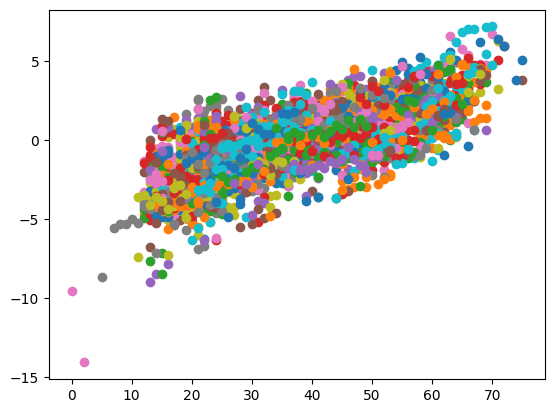

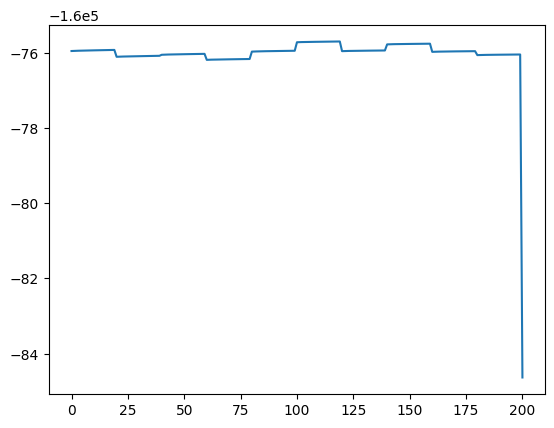

In [53]:
# initial 
# y_lims, list_mod, stats = retirement_prio.fit_type_y(df_stat, N=10, M = 10)

#avec chargement du résultat précédent
stats, list_mod, y_lims = retirement_prio.load_prop(title = 'TAA_propension3')
stats = np.where(np.isnan(stats),0, stats)
y_lims, list_mod, stats = retirement_prio.fit_type_y(df_stat, N=10, M = 20, vals = stats.T)
retirement_prio.save_prop(stats.transpose(),list_mod,y_lims, title = 'TAA_propension')

# Assignment model

## Loading data

In [2]:
y_min = 1990
y_max = 2024 #pour le modèle entraîné

ac_ICAO_names = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Travail de Tobias\Technical Data Aircrafts//aircraft_codes_icao_joined.csv', sep = ';')
print('If one wishes to merge bts and ec, then it requires, ec formalism (less strict), and identifying the type with the ICAO_Code, not Description')
ac_ICAO_names.rename(columns = {'AIRCRAFT_TYPE' : 'Aircraft Type','Description':'Aircraft Type Name'}, inplace = True)
ac_ICAO_names['Aircraft Type'] = ac_ICAO_names['Aircraft Type'].astype(str)

traff_1 = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts\data_full_airlines\\' + str(y_min) + '\T_T100_SEGMENT_ALL_CARRIER.csv')
for y in range(y_min+1, y_max+1):
    if y%5 == 0 :
        print(y)
    df = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts\data_full_airlines\\' + str(y) + '\T_T100_SEGMENT_ALL_CARRIER.csv')
    traff_1 = pd.concat([traff_1, df], ignore_index=True)

traff_1.rename(columns = {'ORIGIN_AIRPORT_ID' : 'ADEP','DEST_AIRPORT_ID': 'ADES', 'YEAR':'Period', 'DEPARTURES_PERFORMED': 'N_flights','DISTANCE':'Distance',
                          'AIRCRAFT_TYPE': 'Aircraft Type', 'UNIQUE_CARRIER' : 'Aircraft Operator','UNIQUE_CARRIER_NAME':'Aircraft Operator Name', 'SEATS': 'Seats'}, inplace = True)  
traff_1['Aircraft Type'] = traff_1['Aircraft Type'].astype(str)
traff_1 = pd.merge(traff_1, ac_ICAO_names[['Aircraft Type', 'Aircraft Type Name']], on = ['Aircraft Type'])

traff_1 = traff_1[(traff_1['Seats']>0)]
traff_1 = traff_1[traff_1['N_flights']>0]
traff_1['Distance'] = traff_1['Distance']*1.852
traff_1 = traff_1[traff_1['Distance']>80] #filtres sur le noùbre de km
traff_1['ADEP Name'] = traff_1['ADEP'] #a adapter bien sur
traff_1['ADES Name'] = traff_1['ADES'] #a adapter bien sur
traff_1.drop(columns=['PASSENGERS'], inplace = True)
print('Poids')
airports = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts//T_MASTER_CORD.csv')[['AIRPORT_ID','AIRPORT_COUNTRY_NAME']]
airports_us = airports[airports['AIRPORT_COUNTRY_NAME']=='United States']
airports_not_us = airports[airports['AIRPORT_COUNTRY_NAME']!='United States']
us_id = airports_us['AIRPORT_ID'].unique() #contient porto rico et des iles
not_us_id = airports_not_us['AIRPORT_ID'].unique() #contient porto rico et des iles (priorité aux us)
# print(traff_1.shape,traff_1['ADES'].isin(us_id).sum()+(traff_1['ADES'].isin(not_us_id)&(~traff_1['ADES'].isin(us_id))).sum()) #ok à quelques vols près
traff_1['Weight']= 0
traff_1.loc[traff_1['ADES'].isin(us_id), 'Weight']+=0.5
traff_1.loc[traff_1['ADEP'].isin(us_id), 'Weight']+=0.5

traff_1 = assignment_analysis.agg_ind(traff_1) 
print('ok')

If one wishes to merge bts and ec, then it requires, ec formalism (less strict), and identifying the type with the ICAO_Code, not Description
1995
2000
2005
2010
2015
2020
Poids
synthesis...
ok


In [3]:
traff_2 = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_market_an_agg.csv')
traff_2.drop(columns=['Unnamed: 0','Siege_ADES', 'Siege_ADEP', 'Siege'], inplace = True)
traff_2['mean_distance'] = traff_2['mean_distance']*1.852
traff_2.rename(columns ={'AC Type':'Aircraft Type', 'AC Operator':'Aircraft Operator', 'echantillon':'Period', 
                         'Taille_f':'Seats', 'tau':'Weight', 'mean_distance':'Distance'}, inplace = True)
traff_2['ADEP Name']=traff_2['ADEP']
traff_2['ADES Name']=traff_2['ADES']
traff_2['Aircraft Type Name']= traff_2['Aircraft Type']
traff_2['Aircraft Operator Name']=traff_2['Aircraft Operator']
traff_2 = assignment_analysis.agg_ind(traff_2) 


traff_2['Seats_conn_p'] = traff_2['Seats_conn_p']*12
traff_2['ASK_conn_p'] = traff_2['ASK_conn_p']*12

synthesis...


## Data visualisation (#peut être à revoir pour séparer les densités d'affichage de la fréquentation par connection)

In [3]:
assignment_analysis.market_vis(traff_2[traff_2['Period'].isin([16,17,18,19])], name_fig = 'Eurocontrol_cie_w',reso = 400, smooth_param = 0.05, 
                                  market = 'Aircraft Operator', observation = 'ASK', dist_limits = [2.5e2, 1.6e4], 
                                  capac_limits = [4.9e3, 4.9e6], n_market = 19, weight = True)
# traff_2.loc[traff_2['Period'].isin([17,18]),'Period'] = -1
# traff_2.loc[traff_2['Period'].isin([16,19]),'Period'] = -2
# ####on corrige un facteur 6 dans les tailles de graphe
# assignment_analysis.dynamic_market_vis(traff_2, [-1,-2],name_periods = ['Summer 2019', 'Winter 2019'], video_name = 'test_market_Type',reso = 300, smooth_param = 0.05, 
#                                   market = 'Aircraft Type', observation = 'ASK', dist_limits = [2.5e2, 1.6e4], period_ref = -2,
#                                   capac_limits = [4.9e3, 4.9e6], n_market = 16, format_v='video', period_duration = 1, weight = True)

In [38]:
assignment_analysis.market_vis(traff_1[traff_1['Period'].isin([2024])], name_fig = 'market_bts_2024',reso = 400, smooth_param = 0.07, 
                                  market = 'Aircraft Type', observation = 'ASK', dist_limits = [1.5e2, 1.9e4], 
                                  capac_limits = [2e3, 6e6], n_market = 15, period_duration = 1, weight = False)

In [139]:
assignment_analysis.assign_vis(traff_1[traff_1['Period'].isin([1990,1991])], [715], title_fig = '715', name_fig = 'test_assign',reso = 400, smooth_param = 0.07, 
                                  market = 'Aircraft Type', observation = 'ASK', dist_limits = [1.5e2, 1.9e4], 
                                  capac_limits = [2e3, 6e6], vmax = 0.5, period_duration = 1)

In [140]:
assignment_analysis.dynamic_market_vis(traff_1, [i for i in range(1990,2025)], video_name = 'test_market_Type',reso = 400, smooth_param = 0.05, 
                                  market = 'Aircraft Type', observation = 'ASK', dist_limits = [1.5e2, 1.9e4], period_ref = 2024,
                                  capac_limits = [2e3, 6e6], n_market = 18, format_v='video')

Color choice...
Coloriage trouvé : {626: 0, 622: 1, 694: 2, 819: 3, 655: 4, 627: 5, 619: 6, 614: 7, 698: 8, 612: 9, 696: 10, 817: 11, 625: 12, 699: 11, 637: 12, 715: 13, 620: 14, 732: 15, 873: 16, 624: 13, 882: 14, 640: 9, 740: 17, 616: 18, 687: 15, 887: 16, 816: 7, 730: 8, 617: 19, 629: 17, 675: 19, 760: 5, 888: 6, 889: 13, 634: 18, 673: 4, 638: 17, 359: 18, 693: 10, 631: 15, 722: 3, 691: 16, 721: 17, 838: 19, 765: 18, 608: 14, 690: 2, 733: 17, 710: 16, 697: 10, 874: 14, 839: 1}
0.0%
8.571428571428571%
17.142857142857142%
25.714285714285715%
34.285714285714285%
42.857142857142854%
51.42857142857143%
60.0%
68.57142857142857%
77.14285714285714%
85.71428571428571%
94.28571428571429%


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1000) to (1408, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [137]:
assignment_analysis.dynamic_assign_vis(traff_1, [715], [1990,1991,1992,1993,1994], format = 'gif', video_name = '715_assign', market = 'Aircraft Type',
                                       observation = 'ASK', dist_limits = [1.5e2, 1.9e4], capac_limits = [2e3, 6e6],
                                      frame_s = 2, color = 'pink', reso = 400, smooth_param = 0.05, period_duration = 1, vmax = 0.5)

0.0%
60.0%


## Model training & evaluation

In [5]:
### data preparation
obs_choice = 'ASK'
ds_name='bts'#BTS : 'bts', EUROCONTROL : 'ec'
n_choice = 35
d_norm, cap_norm = 15000, 15

if ds_name == 'bts' :
    traff_s = traff_1[(traff_1['Period']>=2015) & (traff_1['Period']<=2019)]
    traff_cond = traff_s[['Aircraft Type','Aircraft Type Name', 'Period', 'Distance_conn (km)', 'Weight', 'Seats_conn_p', 'ASK_conn_p', 'ASK','N_flights', 'Seats']].groupby(
        ['Aircraft Type','Aircraft Type Name', 'Period', 'Distance_conn (km)', 'Weight', 'Seats_conn_p', 'ASK_conn_p']).sum().reset_index()
    df_training, c_table, existence_cache, ranges, connections = assignment_multilogit.data_formatting(traff_cond, n_ac= n_choice, seuils_f = 0.01, weight = True,
                                                                                                   obs = obs_choice, save_techn_carac = True) #True seulement pour bts
if ds_name == 'ec' :
    traff_s = traff_2[(traff_2['Period']<=19)]
    traff_cond = traff_s[['Aircraft Type','Aircraft Type Name', 'Period', 'Distance_conn (km)', 'Weight', 'Seats_conn_p', 'ASK_conn_p', 'ASK', 'Seats']].groupby(
        ['Aircraft Type','Aircraft Type Name', 'Period', 'Distance_conn (km)', 'Weight', 'Seats_conn_p', 'ASK_conn_p']).sum().reset_index()
    df_training, c_table, existence_cache, ranges, connections = assignment_multilogit.data_formatting(traff_cond, n_ac= n_choice, seuils_f = 0.01, weight = True,
                                                                                                   obs = obs_choice, save_techn_carac = False) #True seulement pour bts

n_y = existence_cache.shape[1]
data_training = np.array(df_training[['Period','Distance_conn (km)','Seats_conn_p','Id_mod',obs_choice+'_w']]) 
obs_norm = data_training[:,4].sum() #les références de d_norm et cap_norm sont fixes dans les modèles
data_training[:,1] = data_training[:,1]/d_norm
data_training[:,2] = np.log(data_training[:,2])/cap_norm
data_training[:,4] = data_training[:,4]/obs_norm

98.4% ASKs selected.


In [6]:
# alphas, betas, omegas, likely = assignment_multilogit.fit_function(data_training, existence_cache, ranges, num_epochs = 50, learning_rate = 0.3, n_y = n_y, n_ac = n_choice, 
#                                                                  title = 'logit_model_'+ds_name+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(1),
#                                                                    names_ac =list(c_table['Aircraft Type Name']), n_batches = 30)
# alphas, betas, omegas, likely = assignment_multilogit.fit_function(data_training, existence_cache, ranges, num_epochs = 100, learning_rate = 0.2, n_y = n_y, n_ac = n_choice, 
#                                                                  title = 'logit_model_'+ds_name+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(2),
#                                                                    names_ac =list(c_table['Aircraft Type Name']), n_batches = 5,
#                                                                   alphas = alphas, betas = betas, omegas = omegas)
# alphas, betas, omegas, likely = assignment_multilogit.fit_function(data_training, existence_cache, ranges, num_epochs = 100, learning_rate = 0.2, n_y = n_y, n_ac = n_choice, 
#                                                                  title = 'logit_model_'+ds_name+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(3),
#                                                                    names_ac =list(c_table['Aircraft Type Name']), n_batches = 2,
#                                                                   alphas = alphas, betas = betas, omegas = omegas)
alphas, betas, omegas = assignment_multilogit.load_estim(name ='logit_model_'+ds_name+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(4)+'_7')
alphas, betas, omegas, likely = assignment_multilogit.fit_function(data_training, existence_cache, ranges, num_epochs = 500, learning_rate = 0.1, n_y = n_y, n_ac = n_choice, 
                                                                 title = 'logit_model_'+ds_name+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(1),
                                                                   names_ac =list(c_table['Aircraft Type Name']), n_batches = 1,
                                                                  alphas = alphas, betas = betas, omegas = omegas)



Without training -2.22412
epoch 0; Log-likelihood = -2.20947
epoch 1; epoch 2; epoch 3; epoch 4; epoch 5; Log-likelihood = -2.19422
epoch 6; epoch 7; epoch 8; epoch 9; epoch 10; Log-likelihood = -2.19492
epoch 11; epoch 12; epoch 13; epoch 14; epoch 15; Log-likelihood = -2.19197
epoch 16; epoch 17; epoch 18; epoch 19; epoch 20; Log-likelihood = -2.19172
epoch 21; epoch 22; epoch 23; epoch 24; epoch 25; Log-likelihood = -2.1906
epoch 26; epoch 27; epoch 28; epoch 29; epoch 30; Log-likelihood = -2.1904
epoch 31; epoch 32; epoch 33; epoch 34; epoch 35; Log-likelihood = -2.18985
epoch 36; epoch 37; epoch 38; epoch 39; epoch 40; Log-likelihood = -2.18957
epoch 41; epoch 42; epoch 43; epoch 44; epoch 45; Log-likelihood = -2.18936
epoch 46; epoch 47; epoch 48; epoch 49; epoch 50; Log-likelihood = -2.18909
epoch 51; epoch 52; epoch 53; epoch 54; epoch 55; Log-likelihood = -2.18895
epoch 56; epoch 57; epoch 58; epoch 59; epoch 60; Log-likelihood = -2.18876
epoch 61; epoch 62; epoch 63; epoch 64

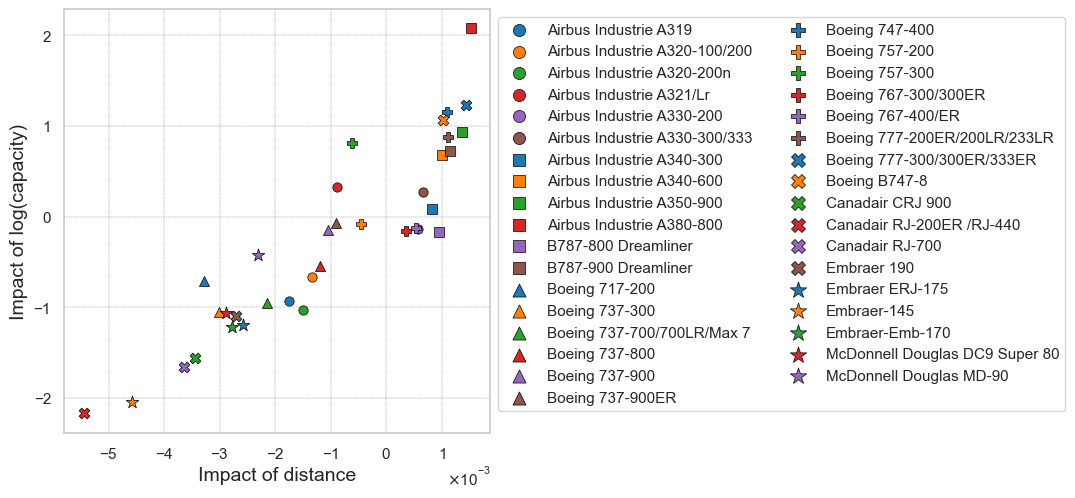

avg relative error : 0.0016496194264257907
obs_weighted avg relative error : 0.0019140624426929162


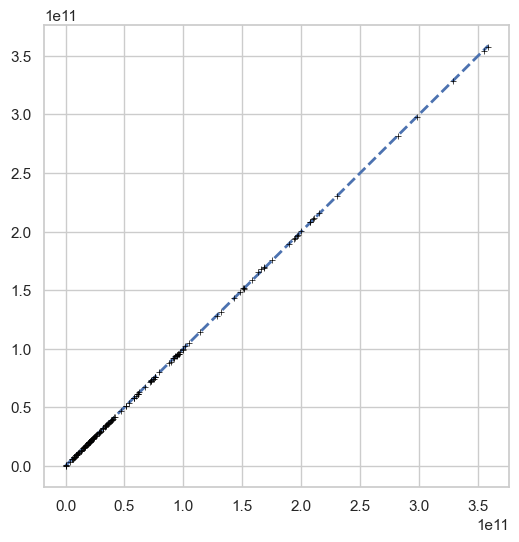

0.04797221054880181 0.12023476239594098


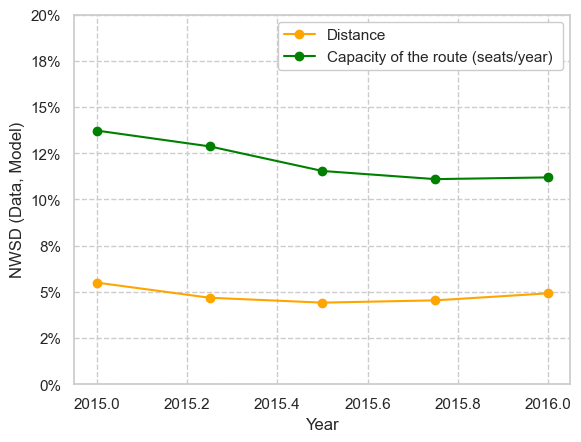

In [74]:
alphas, betas, omegas, names_ac = assignment_multilogit.load_estim(name ='logit_model_'+ds_name+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(1)+'_9', columns = True)
assignment_multilogit.visu_coeffs(alphas, betas, names_ac,ds_name, d_norm = d_norm, cap_norm= cap_norm)
connec_training = np.array(connections[['Period', 'Distance_conn (km)','Seats_conn_p',obs_choice+'_w_mod']])
shares_pred = assignment_multilogit.predict_assignt(connec_training, existence_cache,alphas,betas,omegas,ranges, d_norm=d_norm, cap_norm=cap_norm)
assignment_multilogit.obs_comp(data_training, connec_training, shares_pred, obs_norm)
assignment_multilogit.nwsd(existence_cache, data_training, connec_training, shares_pred, d_norm, cap_norm,obs_norm, year_ref = 2015, freq = 4)

In [105]:
#strictement réservé à BTS, associé à une bdd technique.
correspondance_table = assignment_multilogit.correspondance_table(title_coeffs = 'logit_model_bts_35_5_1_9',title_tech = 'BTS_35_4', obs_choice = 'ASK', d_norm = d_norm, cap_norm= cap_norm)
coeffs_alphas, coeffs_betas =assignment_multilogit.regressor_assign_coeffs(correspondance_table, weight = True, obs_choice = obs_choice)
coeffs_alphas_w, coeffs_betas_w = assignment_multilogit.regressor_assign_coeffs(correspondance_table)
assignment_multilogit.regressor_visu_model(correspondance_table,coeffs_alphas, coeffs_betas, reg_name='bts_35_5')
assignment_multilogit.regressor_visu_model(correspondance_table,coeffs_alphas_w, coeffs_betas_w, reg_name='bts_35_5_w')
alpha_mod, beta_mod = assignment_multilogit.assign_coeffs_pred(coeffs_alphas_w, coeffs_betas_w, 180, 9000)

# Productivité des avions

## Loading data

In [4]:
individual_stops = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_ind_anal.csv')
individual_stops.drop(columns=['Unnamed: 0.1', 'Unnamed: 0','Taille_f', 
                               'Siege_ADES', 'Siege_ADEP', 'Siege', 'Tot siege', 'mean_distance','Actual Distance Flown (nm)'],
                     inplace = True)
individual_stops.rename(columns={'AC Type': 'Aircraft Type', 'AC Operator':'Aircraft Operator','AC Registration':'Aircraft Registration',
                                 'ADES_nf': 'ADES +1', 'ADEP_nf' : 'ADEP +1', 'ADEP_pf': 'ADEP -1', 'ADES_pf': 'ADES -1',
                                'echantillon':'Period','time_delta': 'Real Flight Duration', 'time_delta2':'Planned Flight Duration',
                                'time_delta_nf': 'Real Flight Duration +1', 'time_delta2_nf':'Planned Flight Duration +1',
                                 'time_delta_pf': 'Real Flight Duration -1', 'time_delta2_pf':'Planned Flight Duration -1',
                                 'delta_flights' : 'Ground Time', 'delta_pre_flights' : 'Ground Time -1'}, inplace = True)

In [4]:
flights_streaks = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_long_anal.csv')
flights_streaks['FILED OFF BLOCK TIME'] = pd.to_datetime(flights_streaks['FILED OFF BLOCK TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED ARRIVAL TIME'] = pd.to_datetime(flights_streaks['FILED ARRIVAL TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED OFF BLOCK TIME'] = pd.to_datetime(flights_streaks['ACTUAL OFF BLOCK TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED ARRIVAL TIME'] = pd.to_datetime(flights_streaks['ACTUAL ARRIVAL TIME'], utc=True).dt.tz_localize(None)
flights_streaks.drop(columns=['Unnamed: 0.2','Unnamed: 0.1', 'Unnamed: 0','Taille_f', 'ADES_nf', 'ADEP_nf',
                              'ADEP_pf', 'ADES_pf','time_delta','time_delta2', 'time_delta_nf', 'time_delta2_nf',
                                 'time_delta_pf', 'time_delta2_pf','delta_flights' , 'delta_pre_flights',
                               'Siege_ADES', 'Siege_ADEP', 'Siege', 'Tot siege', 'mean_distance','Actual Distance Flown (nm)'],
                     inplace = True)
flights_streaks.rename(columns={'AC Type': 'Aircraft Type', 'AC Operator':'Aircraft Operator','AC Registration':'Aircraft Registration',
                                'echantillon':'Period'}, inplace = True)

In [2]:
traff_2 = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_market_an_agg.csv')

In [7]:
flights_streaks= flights_streaks[flights_streaks['echantillon']<20]
print(flights_streaks[flights_streaks['Actual Distance Flown (nm)']<1500/1.852].shape)
print(flights_streaks[flights_streaks['Actual Distance Flown (nm)']>4000/1.852].shape)
print(flights_streaks[(flights_streaks['Actual Distance Flown (nm)']>1500/1.852)&(flights_streaks['Actual Distance Flown (nm)']<4000/1.852)].shape)
print(flights_streaks[['Actual Distance Flown (nm)','AC Registration','echantillon']].groupby(['AC Registration','echantillon']).count().shape)
print(flights_streaks[['Actual Distance Flown (nm)','AC Registration']].groupby(['AC Registration']).count().shape)
flights_streaks.drop(columns=['Unnamed: 0.2','Unnamed: 0.1', 'Unnamed: 0','Taille_f', 'ADES_nf', 'ADEP_nf',
                              'ADEP_pf', 'ADES_pf','time_delta','time_delta2', 'time_delta_nf', 'time_delta2_nf',
                                 'time_delta_pf', 'time_delta2_pf','delta_flights' , 'delta_pre_flights',
                               'Siege_ADES', 'Siege_ADEP', 'Siege', 'Tot siege', 'mean_distance','Actual Distance Flown (nm)'],
                     inplace = True)
flights_streaks.rename(columns={'AC Type': 'Aircraft Type', 'AC Operator':'Aircraft Operator','AC Registration':'Aircraft Registration',
                                'echantillon':'Period'}, inplace = True)

(5639644, 32)
(415021, 32)
(1718777, 32)
(58177, 1)
(4752, 1)


## Data visualisation individual stops

In [98]:
productivity_analysis.GT_density(individual_stops, name_fig = 'GT_density_2',sigma = 0.005, reso = 1000)

In [5]:
productivity_analysis.TATs_matrix(individual_stops, name_fig= 'Full_df', reso = 1000, sigma = 0.015)

5.4% are not b&f flights


## Data visualisation flight streaks

In [27]:
aircraft_ex = flights_streaks[(flights_streaks['Aircraft Registration']=='FGZNR')&(flights_streaks['Period']==17)] #B77w
x_min = productivity_analysis.visu_distrib(aircraft_ex, titre = 'hour_distrib_A320', visu = True, visu_c = True)[0]
productivity_analysis.visu(aircraft_ex, titre = 'B77W', visu = True, x_min = x_min)


In [34]:
L_NB = ['B738', 'A320', 'A319', 'A20N', 'A321', 'A21N', 'B38M', 'B752','B737',  'B739','A318',
        'B712','B733','B736','B735','B753','MD11','MD82','B39M','B734'] #NB classiques
LC = ['RYR', 'EZY', 'WZZ', 'VLG']
LL = ['AFR', 'KLM', 'BAW', 'DLH', 'SAS', 'TAP', 'IBE', 'SWR']
selec = flights_streaks[(flights_streaks['Aircraft Type'].isin(L_NB))&(flights_streaks['Period']<20)
    &((flights_streaks['Period']%4 == 1)|(flights_streaks['Period']%4 == 2))]
flight_grouping = productivity_analysis.constru_flight_streak(selec)
productivity_analysis.visu_flight_streaks(flight_grouping,title = 'regimes_hs', min_fh = 0.5, 
                                          max_fh = 6,reso = 400, sigma = 0.02, n_s = 3)

0%, 5%, 10%, 15%, 20%, 25%, 30%, 35%, 40%, 45%, 50%, 55%, 60%, 65%, 70%, 75%, 80%, 85%, 90%, 95%, 100%, 100 %, ok.
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, ok.


In [37]:
selec = flights_streaks[(flights_streaks['Period']<20)&(flights_streaks['Aircraft Type'].isin(['A332', 'A333']))]
flight_grouping = productivity_analysis.constru_flight_streak(selec)
productivity_analysis.visu_flight_streaks(flight_grouping,title = 'regimes_a33', min_fh = 2, 
                                          max_fh = 14,reso = 400, sigma = 0.03, n_s = 2)

0%, 5%, 10%, 15%, 20%, 25%, 30%, 35%, 40%, 45%, 50%, 55%, 60%, 65%, 70%, 75%, 80%, 85%, 90%, 95%, 100 %, ok.
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, ok.


In [38]:
flight_grouping_2 = flight_grouping[flight_grouping[:,1]/flight_grouping[:,3]>0]
productivity_analysis.streaks_matrix(flight_grouping_2,title = 'streak_matrix_a33', min_fh = 0.5, 
                                          max_fh = 14,reso = 1000, sigma = 0.02)

## Model training

#La suite ?